In [1]:
# ------------------------------------------------------------
# Notebook 01 — Preprocessing (Vibe Coding Style)
# BiofilmAI — Gene Expression → Biofilm Prediction
# ------------------------------------------------------------

# Step 1: Load libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="deep")


In [2]:
# ------------------------------------------------------------
# Step 2: Load raw differential expression tables
# ------------------------------------------------------------

biofilm_raw = pd.read_csv("../data/gene_expression/GSE87213_biofilm_DE_cleaned.csv")
planktonic_raw = pd.read_csv("../data/gene_expression/GSE87213_planktonic_DE_cleaned.csv")

print("Biofilm table:", biofilm_raw.shape)
print("Planktonic table:", planktonic_raw.shape)


Biofilm table: (5983, 21)
Planktonic table: (5973, 21)


In [3]:
# ------------------------------------------------------------
# Step 3: Rename columns for clarity
# ------------------------------------------------------------

biofilm = biofilm_raw.rename(columns={
    "log_FC": "biofilm_logFC",
    "deseq.adj.pvalue": "biofilm_padj"
})

planktonic = planktonic_raw.rename(columns={
    "log_FC": "planktonic_logFC",
    "deseq.adj.pvalue": "planktonic_padj"
})


In [4]:
# ------------------------------------------------------------
# Step 4: Merge biofilm + planktonic tables
# ------------------------------------------------------------

merged = biofilm.merge(
    planktonic[["gene_symbol", "planktonic_logFC", "planktonic_padj"]],
    on="gene_symbol",
    how="inner"
)

print("Merged table:", merged.shape)
merged.head()


Merged table: (7563, 23)


,id,gene_symbol,biofilm_logFC,log_CPM,deseq.p-value,biofilm_padj,edger.p.value,edger.adj.p.value,X3225B2.norm,X3225B3.norm,...,WTB6.norm,X3225B2.raw,X3225B3.raw,X3225B4.raw,WTB3.raw,WTB4.raw,WTB6.raw,log2FoldChange_norm,planktonic_logFC,planktonic_padj
0,PA14_22460,PA14_22460,4.345,7.733,2.000000e-71,1.200000e-67,4.600000e-80,1.400000e-76,1686,1573,...,62,1956,1711,1200,122,60,73,4.345,4.044,2.400000e-99
1,PA14_22450,ppiA,4.151,7.630,1.000000e-66,3.000000e-63,2.400000e-85,1.400000e-81,1574,1537,...,89,1826,1672,1036,104,62,103,4.151,3.982,9.800000e-124
2,PA14_22470,PA14_22470,3.929,9.077,8.800000e-66,1.700000e-62,1.800000e-75,3.500000e-72,4458,3785,...,269,5171,4117,2938,369,179,313,3.929,3.617,4.900000e-133
3,PA14_22440,bapA,3.773,8.996,3.000000e-62,4.400000e-59,1.100000e-73,1.600000e-70,3877,3928,...,245,4497,4272,2704,377,222,285,3.773,3.418,3.000000e-91
4,PA14_27070,PA14_27070,3.263,9.016,1.400000e-49,1.600000e-46,2.100000e-53,2.500000e-50,4260,3546,...,458,4941,3857,2582,421,292,531,3.263,3.031,1.800000e-103


In [5]:
# ------------------------------------------------------------
# Step 5: Engineer basic ML features
# ------------------------------------------------------------

merged["biofilm_abs_logFC"] = merged["biofilm_logFC"].abs()
merged["planktonic_abs_logFC"] = merged["planktonic_logFC"].abs()

merged["biofilm_significant"] = (merged["biofilm_padj"] < 0.05).astype(int)
merged["planktonic_significant"] = (merged["planktonic_padj"] < 0.05).astype(int)

merged["biofilm_label"] = merged["biofilm_significant"]

merged.head()


,id,gene_symbol,biofilm_logFC,log_CPM,deseq.p-value,biofilm_padj,edger.p.value,edger.adj.p.value,X3225B2.norm,X3225B3.norm,...,WTB4.raw,WTB6.raw,log2FoldChange_norm,planktonic_logFC,planktonic_padj,biofilm_abs_logFC,planktonic_abs_logFC,biofilm_significant,planktonic_significant,biofilm_label
0,PA14_22460,PA14_22460,4.345,7.733,2.000000e-71,1.200000e-67,4.600000e-80,1.400000e-76,1686,1573,...,60,73,4.345,4.044,2.400000e-99,4.345,4.044,1,1,1
1,PA14_22450,ppiA,4.151,7.630,1.000000e-66,3.000000e-63,2.400000e-85,1.400000e-81,1574,1537,...,62,103,4.151,3.982,9.800000e-124,4.151,3.982,1,1,1
2,PA14_22470,PA14_22470,3.929,9.077,8.800000e-66,1.700000e-62,1.800000e-75,3.500000e-72,4458,3785,...,179,313,3.929,3.617,4.900000e-133,3.929,3.617,1,1,1
3,PA14_22440,bapA,3.773,8.996,3.000000e-62,4.400000e-59,1.100000e-73,1.600000e-70,3877,3928,...,222,285,3.773,3.418,3.000000e-91,3.773,3.418,1,1,1
4,PA14_27070,PA14_27070,3.263,9.016,1.400000e-49,1.600000e-46,2.100000e-53,2.500000e-50,4260,3546,...,292,531,3.263,3.031,1.800000e-103,3.263,3.031,1,1,1


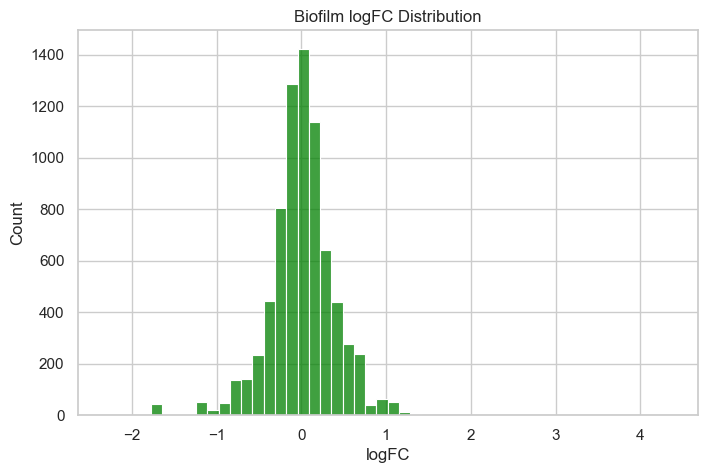

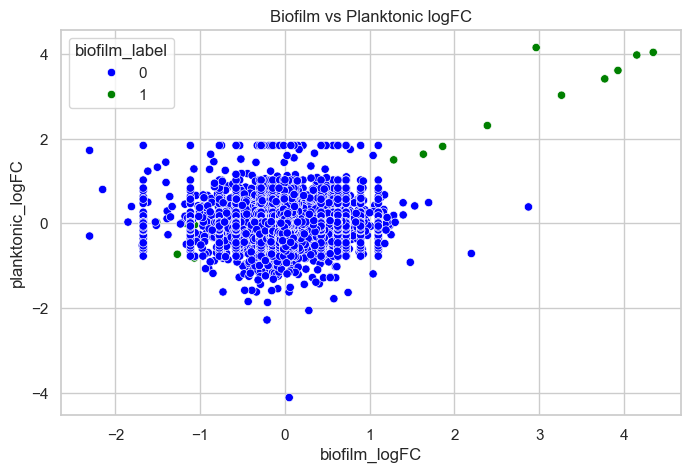

In [6]:
# ------------------------------------------------------------
# Step 6: Visual intuition checks (Vibe Coding)
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
sns.histplot(merged["biofilm_logFC"], bins=50, color="green")
plt.title("Biofilm logFC Distribution")
plt.xlabel("logFC")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=merged,
    x="biofilm_logFC",
    y="planktonic_logFC",
    hue="biofilm_label",
    palette={0: "blue", 1: "green"}
)
plt.title("Biofilm vs Planktonic logFC")
plt.show()


In [7]:
# ------------------------------------------------------------
# Step 7: Save machine learning feature table
# ------------------------------------------------------------

merged.to_csv("../data/gene_expression/biofilm_ml_features.csv", index=False)
print("Saved ML feature table.")


Saved ML feature table.


In [8]:
# ------------------------------------------------------------
# Step 8: Summary (Vibe Coding narrative)
# ------------------------------------------------------------

print("""
Preprocessing complete.

This notebook:
- loaded raw differential expression tables
- cleaned and renamed columns
- merged biofilm + planktonic conditions
- engineered ML features
- added significance flags
- created a biofilm label
- generated visual intuition checks
- saved the final ML feature table

Ready for Notebook 02 — Feature Engineering.
""")



Preprocessing complete.

This notebook:
- loaded raw differential expression tables
- cleaned and renamed columns
- merged biofilm + planktonic conditions
- engineered ML features
- added significance flags
- created a biofilm label
- generated visual intuition checks
- saved the final ML feature table

Ready for Notebook 02 — Feature Engineering.

